In [18]:
import pandas as pd 
import numpy as np
import os   
import main
from config import update_config
from tqdm import tqdm
from config_loader import get_config
from transform import (
    image_processing,
    landmark_processing,
    segmentation_processing,
    wing_processing,
)
from predictor import prediction
import utils
import matplotlib.pyplot as plt

/Volumes/VecEcoHDD/DO_NOT_DELETE-backup/WingImages_Database_v3/Psychodidae/psychodidae_ecosap_f_l_41c458ec3806.tif
Landmark detection status: Full Skeleton


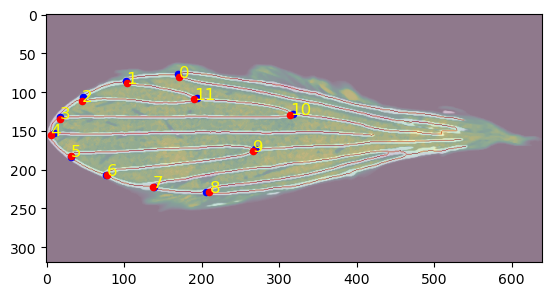

In [4]:
file_list = os.listdir("/Volumes/VecEcoHDD/DO_NOT_DELETE-backup/WingImages_Database_v3/Psychodidae")
file_list = [f for f in file_list if f.endswith('.tif') and not f.startswith('.')]
file_name = os.path.join("/Volumes/VecEcoHDD/DO_NOT_DELETE-backup/WingImages_Database_v3/Psychodidae", file_list[-1000])
print(file_name)

def run_prediction(file, save_path, family, timing_info=None, stream=True, save_image=True, num_landmarks_ref="default"):
    
    # Update global CONFIG for this family (so transform modules use correct config)
    update_config(family)
    # Get configuration for specified family
    CONFIG = get_config(family)

    image_aligned, mask_aligned, mask = image_processing.process_image(file, from_stream=False)

    image_ithildin = image_processing.transform_image(
        image_aligned,
        mask_aligned,
        contrast="Soft",
        resize_size=640,
    )
    segmentation_sigmoid, segmentation_logit = prediction.run_segmentation(image_ithildin, family)

    image_landmark = image_processing.resize(
        image_ithildin, CONFIG["landmark_image_size"][0]
    )
    segmentation_landmark = image_processing.resize(
        segmentation_sigmoid, CONFIG["landmark_image_size"][0]
    )

    landmarks = prediction.run_landmark_detection(image_landmark, segmentation_landmark, family)
    landmarks_coord = landmark_processing.heatmap_to_coordinates(landmarks)

    skeleton = segmentation_processing.skeletonize(segmentation_sigmoid)
    junctions_coord = segmentation_processing.extract_junction_coordinates(skeleton)
    consensus_coord = landmark_processing.consensus_coordinates(
        landmarks_coord, junctions_coord, skeleton
    )
    repaired_skeleton, status, failed_coord = wing_processing.check_skeleton(
        skeleton, consensus_coord, segmentation_logit
    )

    # Step 6: Re-extract if skeleton was repaired
    if status == "Repaired":
        repaired_skeleton, _, failed_coord = wing_processing.check_skeleton(
            repaired_skeleton, consensus_coord, segmentation_logit
        )

    print(f"Landmark detection status: {status}")

    return image_ithildin, segmentation_sigmoid, landmarks_coord, consensus_coord, repaired_skeleton, landmarks

image_ithildin, segmentation_sigmoid, landmarks_coord, consensus_coord, repaired_skeleton, lm_heatmap = run_prediction(file_name,  save_path="test/test", family="psychodidae")
skeleton = segmentation_processing.skeletonize(segmentation_sigmoid)

plt.imshow(image_ithildin)
plt.imshow(segmentation_sigmoid, cmap='gray', alpha=0.5)
plt.imshow(skeleton, cmap='Reds', alpha=0.5)

X = np.asarray(landmarks_coord[0])*640
Y = np.asarray(landmarks_coord[1])*320

X_con = np.asarray(consensus_coord[0])*640
Y_con = np.asarray(consensus_coord[1])*320

plt.scatter(X, Y, c='blue', s=20)
plt.scatter(X_con, Y_con, c='red', s=20)
# Numerate landmarks
for i, (x, y) in enumerate(zip(X_con, Y_con)):
    plt.text(x, y, str(i), color='yellow', fontsize=12)

plt.show()

Landmarks 6, 7, 8, 10 are often missplaced

In [ ]:
df = pd.read_csv("/Users/kristophernolte/Documents/phd_datapaper_v3/00_metadata_v3_darwincore.csv")
df = df[df["taxon_family"] == "Psychodidae"]

# sample 25 from each unique "project"
sampled_df = df.groupby("project").apply(lambda x: x.sample(25, replace=True)).reset_index(drop=True)
file_list = sampled_df["fileName"].values

for file in tqdm(file_list):
    try:
        file_path = os.path.join("/Volumes/VecEcoHDD/DO_NOT_DELETE-backup/WingImages_Database_v3/Psychodidae", file)
        run = main.run_prediction(file_path, save_path=f"test/{file.split('.')[0]}", family="psychodidae", timing_info={}, stream=False, save_image=True)
    except Exception as e:
        print(f"Error processing {file}: {e}")

In [32]:
df_results

,File,Status,Centroid,Orientation,CNN_Predicted_Taxa,CNN_Predicted_Score,X_0,X_1,X_2,X_3,...,Y_3,Y_4,Y_5,Y_6,Y_7,Y_8,Y_9,Y_10,Y_11,File_Name
0,test/psychodidae_moldova-sandfly-sampling_f_r_...,Repaired,2015,right,None,NaN,1944,2325,2545,2680,...,283,391,521,629,716,768,491,253,171,psychodidae_moldova-sandfly-sampling_f_r_ec586...
1,test/psychodidae_moldova-sandfly-sampling_f_r_...,Failed Repair,2463,right,None,NaN,2133,2555,2569,2786,...,203,430,550,777,856,773,518,425,189,psychodidae_moldova-sandfly-sampling_f_r_e17bb...
2,test/psychodidae_benin-sandfly-sampling_m_r_e5...,Full Skeleton,1431,right,None,NaN,1702,1932,2162,2339,...,207,286,387,470,519,542,346,177,124,psychodidae_benin-sandfly-sampling_m_r_e5a91a0...
3,test/psychodidae_ghana-sandfly-sampling_f_l_c1...,Repaired,2124,left,None,NaN,912,662,236,92,...,377,482,609,701,785,649,495,289,214,psychodidae_ghana-sandfly-sampling_f_l_c1da7a6...
4,test/psychodidae_sandlfy-regional-sampling-spa...,Failed Repair,1831,left,None,NaN,601,1850,289,146,...,164,344,439,612,663,516,406,219,150,psychodidae_sandlfy-regional-sampling-spain_f_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,test/psychodidae_ghana-sandfly-sampling_f_l_45...,Failed Repair,2176,left,None,NaN,1020,401,383,87,...,330,450,570,681,815,630,514,302,214,psychodidae_ghana-sandfly-sampling_f_l_4552ced...
138,test/psychodidae_austria-sandfly-sampling_f_r_...,Failed Repair,1924,left,None,NaN,769,493,304,152,...,176,380,493,685,761,701,465,248,252,psychodidae_austria-sandfly-sampling_f_r_bc9cb...
139,test/psychodidae_moldova-sandfly-sampling_m_l_...,Full Skeleton,1590,left,None,NaN,796,444,230,91,...,254,367,472,555,624,672,433,246,154,psychodidae_moldova-sandfly-sampling_m_l_dc78e...
140,test/psychodidae_moldova-sandfly-sampling_f_r_...,Repaired,2011,right,None,NaN,1844,2230,2444,2615,...,321,449,573,672,796,753,565,321,201,psychodidae_moldova-sandfly-sampling_f_r_23f65...


In [35]:
df_results = utils.json_to_dataframe("test/", family="psychodidae")
df_results["project"] = df_results["File"].apply(lambda x: x.split("_")[1])
df_results.groupby("project")["Status"].value_counts()

project                          Status       
austria-sandfly-sampling         Failed Repair    18
                                 Repaired          1
benin-sandfly-sampling           Full Skeleton    21
                                 Repaired          2
                                 Failed Repair     1
ecosap                           Full Skeleton    13
                                 Repaired          7
                                 Failed Repair     4
ghana-sandfly-sampling           Failed Repair     9
                                 Full Skeleton     9
                                 Repaired          7
isidore                          Failed Repair    10
                                 Repaired          2
moldova-sandfly-sampling         Failed Repair    12
                                 Repaired          9
                                 Full Skeleton     2
sandlfy-regional-sampling-spain  Failed Repair    12
                                 Repaired          3

(1600.0, 0.0)

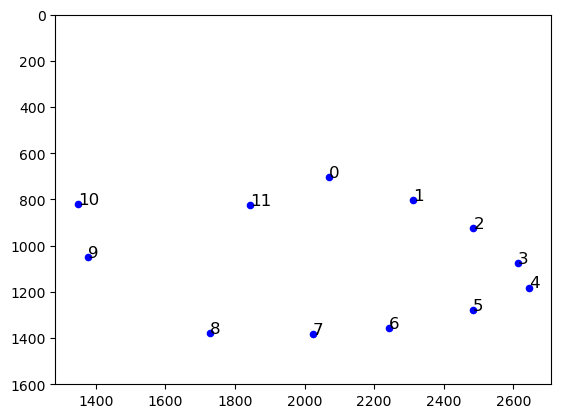

In [9]:
df = pd.read_csv("training/data_psycho/landmark/landmark_annotations_old.csv", sep=";")
df.drop(columns=["X_0", "Y_0", "X_13", "Y_13", "X_14", "Y_14", "X_15", "Y_15"], inplace=True)
df.rename(columns={"X_12": "X_0", "Y_12": "Y_0"}, inplace=True)
df.to_csv("training/data_psycho/landmark/landmark_annotations.csv", index=False, sep=";")

X = df.iloc[0][[x for x in df.columns if x.startswith("X_")]].values
Y = df.iloc[0][[y for y in df.columns if y.startswith("Y_")]].values

plt.scatter(X, Y, c='blue', s=20)
for i, (x, y) in enumerate(zip(X, Y)):
    plt.text(x, y, str(i), color='black', fontsize=12)

plt.ylim(1600, 0) 

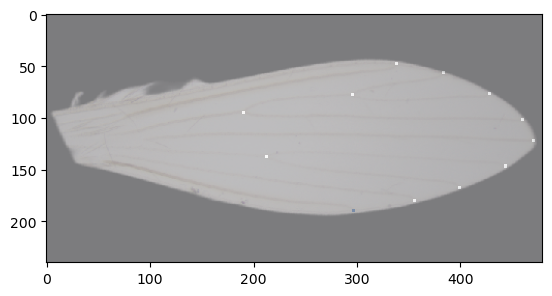

In [31]:
heatmap = np.load("training/data_psycho/landmark/landmark_heatmaps/psychodidae_benin-sandfly-sampling_f_l_1b3c3441ddae_map.npy")
image = plt.imread("training/data_psycho/landmark/image_processed/psychodidae_benin-sandfly-sampling_f_l_1b3c3441ddae.png")
image_480 = image_processing.resize(image, 480)

plt.imshow(image_480)
plt.imshow(np.sum(heatmap, axis=-1), cmap='hot', interpolation='nearest', alpha=0.5)
plt.imshow(heatmap[..., 8], cmap='Blues', interpolation='nearest', alpha=0.5)